# C3M1: Peer Reviewed Assignment

### Outline:
The objectives for this assignment:

1. Apply Binomial regression methods to real data.
2. Understand how to analyze and interpret binomial regression models.
3. Flex our math skills by determining whether certain distributions are members of the exponential family.

General tips:

1. Read the questions carefully to understand what is being asked.
2. This work will be reviewed by another human, so make sure that you are clear and concise in what your explanations and answers.

In [2]:
# Load required libraries
library(tidyverse)
library(dplyr)

── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.1.4     ✔ readr     2.1.5
✔ forcats   1.0.0     ✔ stringr   1.5.2
✔ ggplot2   3.5.2     ✔ tibble    3.3.0
✔ lubridate 1.9.4     ✔ tidyr     1.3.1
✔ purrr     1.1.0     
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors


## Problem 1: Binomial (Logistic) Regression

The National Institute of Diabetes and Digestive and Kidney Diseases conducted a study of 768 adult female Pima Indians living near Phoenix, AZ. The purpose of the study was to investigate the factors related to diabetes. 

*Before we analyze these data, we should note that some have raised ethical issues with its collection and popularity in the statistics and data science community. We should think seriously about these concerns. For example, Maya Iskandarani wrote a brief [piece](https://researchblog.duke.edu/2016/10/24/diabetes-and-privacy-meet-big-data/) on consent and privacy concerns raised by this dataset. After you familarize yourself with the data, we'll then turn to these ethical concerns.*


First, we'll use these data to get some practice with GLM and Logistic regression.

In [3]:
# Load the data
pima = read.csv("pima.txt", sep="\t")
# Here's a description of the data: https://rdrr.io/cran/faraway/man/pima.html
head(pima)

,pregnant,glucose,diastolic,triceps,insulin,bmi,diabetes,age,test
,<int>,<int>,<int>,<int>,<int>,<dbl>,<dbl>,<int>,<int>
1,6,148,72,35,0,33.6,0.627,50,1
2,1,85,66,29,0,26.6,0.351,31,0
3,8,183,64,0,0,23.3,0.672,32,1
4,1,89,66,23,94,28.1,0.167,21,0
5,0,137,40,35,168,43.1,2.288,33,1
6,5,116,74,0,0,25.6,0.201,30,0


### 1. (a) Data Cleaning? What about Data Scrubbing? Data Sterilizing?

This is a real data set, which means that there's likely going to be gaps and missing values in the data. Before doing any modeling, we should inspect the data and clean it if necesary.

Perform simple graphical and numerical summaries of the data. Pay attention for missing or nonsensical values. Can you find any obvious irregularities? If so, take appropriate steps to correct these problems. In the markdown cell, specify what cleaning you did and why you did it.

Finally, split your data into training and test sets. Let the training set contain $80\%$ of the rows and the test set contain the remaining $20\%$.

Data shape: 768 9 

Data types:
'data.frame':	768 obs. of  9 variables:
 $ pregnant : int  6 1 8 1 0 5 3 10 2 8 ...
 $ glucose  : int  148 85 183 89 137 116 78 115 197 125 ...
 $ diastolic: int  72 66 64 66 40 74 50 0 70 96 ...
 $ triceps  : int  35 29 0 23 35 0 32 0 45 0 ...
 $ insulin  : int  0 0 0 94 168 0 88 0 543 0 ...
 $ bmi      : num  33.6 26.6 23.3 28.1 43.1 25.6 31 35.3 30.5 0 ...
 $ diabetes : num  0.627 0.351 0.672 0.167 2.288 ...
 $ age      : int  50 31 32 21 33 30 26 29 53 54 ...
 $ test     : int  1 0 1 0 1 0 1 0 1 1 ...

Summary statistics:
    pregnant         glucose        diastolic         triceps     
 Min.   : 0.000   Min.   :  0.0   Min.   :  0.00   Min.   : 0.00  
 1st Qu.: 1.000   1st Qu.: 99.0   1st Qu.: 62.00   1st Qu.: 0.00  
 Median : 3.000   Median :117.0   Median : 72.00   Median :23.00  
 Mean   : 3.845   Mean   :120.9   Mean   : 69.11   Mean   :20.54  
 3rd Qu.: 6.000   3rd Qu.:140.2   3rd Qu.: 80.00   3rd Qu.:32.00  
 Max.   :17.000   Max.   :199.0   

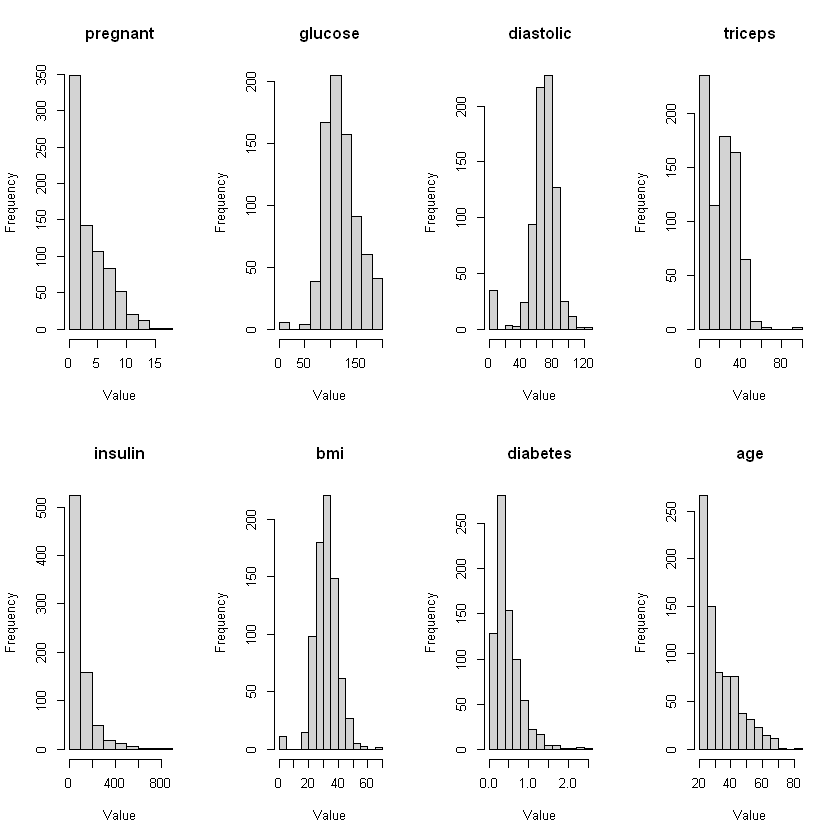

In [10]:
# Inspect the data for missing and nonsensical values
cat("Data shape:", dim(pima), "\n")

cat("\nData types:\n")
str(pima)

cat("\nSummary statistics:\n")
print(summary(pima))

# Check for missing values
cat("\nMissing values per column:\n")
print(colSums(is.na(pima)))

# Check for zero values
cat("\nZero counts per column:\n")
zero_counts <- colSums(pima == 0)
print(zero_counts)

# Identify problematic zero values
cat("\nIssues found:\n")
cat("- Glucose:", sum(pima$glucose == 0), "zero values\n")
cat("- Diastolic:", sum(pima$diastolic == 0), "zero values\n")
cat("- Triceps:", sum(pima$triceps == 0), "zero values\n")
cat("- Insulin:", sum(pima$insulin == 0), "zero values\n")
cat("- BMI:", sum(pima$bmi == 0), "zero values\n")

# Visualize predictors before cleaning
par(mfrow = c(2, 4))
for (i in 1:8) {
  hist(pima[, i], main = colnames(pima)[i], xlab = "Value")
}
par(mfrow = c(1, 1))

# Treat nonsensical zero values as missing and remove incomplete rows
pima_clean <- pima %>%
  mutate(
    glucose = na_if(glucose, 0),
    diastolic = na_if(diastolic, 0),
    triceps = na_if(triceps, 0),
    insulin = na_if(insulin, 0),
    bmi = na_if(bmi, 0)
  ) %>%
  drop_na()

cat("\nData shape after cleaning:", dim(pima_clean), "\n")
cat("Rows removed:", nrow(pima) - nrow(pima_clean), "\n")

# Split into 80% training and 20% test sets
set.seed(123)

n <- nrow(pima_clean)
train_indices <- sample(seq_len(n), size = floor(0.8 * n))

train_data <- pima_clean[train_indices, ]
test_data <- pima_clean[-train_indices, ]

cat("\nTraining set size:", nrow(train_data), "\n")
cat("Test set size:", nrow(test_data), "\n")# Inspect the data for missing and nonsensical values
cat("Data shape:", dim(pima), "\n")

cat("\nData types:\n")
str(pima)

cat("\nSummary statistics:\n")
print(summary(pima))

# Check for missing values
cat("\nMissing values per column:\n")
print(colSums(is.na(pima)))

# Check for zero values
cat("\nZero counts per column:\n")
zero_counts <- colSums(pima == 0)
print(zero_counts)

# Identify problematic zero values
cat("\nIssues found:\n")
cat("- Glucose:", sum(pima$glucose == 0), "zero values\n")
cat("- Diastolic:", sum(pima$diastolic == 0), "zero values\n")
cat("- Triceps:", sum(pima$triceps == 0), "zero values\n")
cat("- Insulin:", sum(pima$insulin == 0), "zero values\n")
cat("- BMI:", sum(pima$bmi == 0), "zero values\n")

# Visualize predictors before cleaning
par(mfrow = c(2, 4))
for (i in 1:8) {
  hist(pima[, i], main = colnames(pima)[i], xlab = "Value")
}
par(mfrow = c(1, 1))

# Treat nonsensical zero values as missing and remove incomplete rows
pima_clean <- pima %>%
  mutate(
    glucose = na_if(glucose, 0),
    diastolic = na_if(diastolic, 0),
    triceps = na_if(triceps, 0),
    insulin = na_if(insulin, 0),
    bmi = na_if(bmi, 0)
  ) %>%
  drop_na()

cat("\nData shape after cleaning:", dim(pima_clean), "\n")
cat("Rows removed:", nrow(pima) - nrow(pima_clean), "\n")

# Split into 80% training and 20% test sets
set.seed(123)

n <- nrow(pima_clean)
train_indices <- sample(seq_len(n), size = floor(0.8 * n))

train_data <- pima_clean[train_indices, ]
test_data <- pima_clean[-train_indices, ]

cat("\nTraining set size:", nrow(train_data), "\n")
cat("Test set size:", nrow(test_data), "\n")

## Summary of Data Cleaning

The data contained nonsensical zero values for glucose, diastolic blood pressure, triceps thickness, insulin, and BMI. I treated these zeros as missing values and removed observations containing them. I then randomly split the cleaned data into 80% training and 20% test sets using set.seed(123).


### 1. (b) Initial GLM modelling


Our data is clean and we're ready to fit! What kind of model should we use to fit these data? Notice that the `test` variable is either $0$ or $1$, for whether the individual tested positive for diabetes. Because `test` is binary, we should use logistic regression (which is a kind of binomial regression).

Fit a model with `test` as the response and all the other variables as predictors. Can you tell whether this model fits the data?

In [5]:
# Fit a logistic (binomial) regression model on the training data
logit_model <- glm(test ~ ., data = train_data, family = binomial(link = "logit"))

# Display coefficient estimates and significance tests
summary(logit_model)

# Summarize in-sample fit relative to an intercept-only model
lr_p_value <- pchisq(
  logit_model$null.deviance - logit_model$deviance,
  df = logit_model$df.null - logit_model$df.residual,
  lower.tail = FALSE
)
pseudo_r_squared <- 1 - logit_model$deviance / logit_model$null.deviance

cat("Likelihood-ratio test p-value:", signif(lr_p_value, 3), "\n")
cat("McFadden pseudo-R-squared:", round(pseudo_r_squared, 3), "\n")


Call:
glm(formula = test ~ ., family = binomial(link = "logit"), data = train_data)

Coefficients:
              Estimate Std. Error z value Pr(>|z|)    
(Intercept) -9.4623789  1.3130977  -7.206 5.76e-13 ***
pregnant     0.0349444  0.0629899   0.555   0.5791    
glucose      0.0377218  0.0065802   5.733 9.89e-09 ***
diastolic   -0.0038727  0.0132082  -0.293   0.7694    
triceps      0.0121760  0.0182904   0.666   0.5056    
insulin     -0.0006239  0.0014416  -0.433   0.6652    
bmi          0.0637682  0.0300119   2.125   0.0336 *  
diabetes     1.1844210  0.4808469   2.463   0.0138 *  
age          0.0357439  0.0207972   1.719   0.0857 .  
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

(Dispersion parameter for binomial family taken to be 1)

    Null deviance: 402.05  on 312  degrees of freedom
Residual deviance: 286.99  on 304  degrees of freedom
AIC: 304.99

Number of Fisher Scoring iterations: 5


Likelihood-ratio test p-value: 3.45e-21 
McFadden pseudo-R-squared: 0.286 


### Model assessment

I fit a binomial logistic regression using all eight predictors. The likelihood-ratio test was significant, $p < 0.001$, indicating that the full model fits significantly better than an intercept-only model. McFadden's pseudo-$R^2$ was $0.286$. Test-set performance will provide a better measure of predictive performance.


### 1. (c) Remember Bayes

A quick analytical interlude.

Is diastolic blood pressure significant in the regression model? Do women who test positive have higher diastolic blood pressures? Explain the distinction between the two questions and discuss why the answers are only apparently contradictory.

In [6]:
# Adjusted association: coefficient from the multivariable logistic model
diastolic_result <- coef(summary(logit_model))["diastolic", ]
print(diastolic_result)

# Unadjusted comparison: observed blood-pressure levels by diabetes status
blood_pressure_by_status <- train_data %>%
  group_by(test) %>%
  summarise(
    n = n(),
    mean_diastolic = mean(diastolic),
    sd_diastolic = sd(diastolic),
    .groups = "drop"
  )
print(blood_pressure_by_status)

# Test the unadjusted difference in mean diastolic blood pressure
unadjusted_diastolic_test <- t.test(diastolic ~ test, data = train_data)
print(unadjusted_diastolic_test)

   Estimate  Std. Error     z value    Pr(>|z|) 
-0.00387270  0.01320818 -0.29320461  0.76936576 
# A tibble: 2 × 4
   test     n mean_diastolic sd_diastolic
  <int> <int>          <dbl>        <dbl>
1     0   206           69.6         12.1
2     1   107           74.1         12.5

	Welch Two Sample t-test

data:  diastolic by test
t = -3.0748, df = 208.17, p-value = 0.002388
alternative hypothesis: true difference in means between group 0 and group 1 is not equal to 0
95 percent confidence interval:
 -7.433780 -1.625471
sample estimates:
mean in group 0 mean in group 1 
       69.58252        74.11215 



### Answer

Diastolic blood pressure was not significant in the logistic regression, with a coefficient of $-0.0039$ and $p = 0.769$. However, women who tested positive had a higher mean diastolic blood pressure, $74.1$ mmHg versus $69.6$ mmHg, with $p = 0.002$. These results are not contradictory because the $t$-test measures the unadjusted difference between groups, while the regression measures the effect of diastolic blood pressure after controlling for the other predictors.


### 1. (d) GLM Interpretation

We've seen so many regression summaries up to this point, how is this one different from all the others? Well, to really understand any model, it can be helpful to loop back and plug the fitted results back into the model's mathematical form.

Explicity write out the equation for the binomial regression model that you fit in (b). Then, in words, explain how a $1$ unit change of `glucose` affects `test`, assuming all other predictors are held constant.

In [7]:
# Extract and interpret the glucose coefficient from the fitted logistic model
glucose_coefficient <- coef(logit_model)["glucose"]
glucose_odds_ratio <- exp(glucose_coefficient)

cat("Glucose coefficient on the log-odds scale:", round(glucose_coefficient, 4), "\n")
cat("Odds ratio for a one-unit glucose increase:", round(glucose_odds_ratio, 4), "\n")
cat("Percent change in odds:", round((glucose_odds_ratio - 1) * 100, 2), "%\n")

Glucose coefficient on the log-odds scale: 0.0377 
Odds ratio for a one-unit glucose increase: 1.0384 
Percent change in odds: 3.84 %


### GLM Interpretation

Let $p = P(\text{test}=1)$. The fitted logistic regression model is

$$
\log\left(\frac{p}{1-p}\right)
=
-9.4624
+ 0.0349(\text{pregnant})
+ 0.0377(\text{glucose})
- 0.0039(\text{diastolic})
+ 0.0122(\text{triceps})
- 0.0006(\text{insulin})
+ 0.0638(\text{bmi})
+ 1.1844(\text{diabetes})
+ 0.0357(\text{age}).
$$

Holding the other predictors constant, a one-unit increase in glucose multiplies the odds of testing positive by

$$
e^{0.0377} \approx 1.0384,
$$

which is about a $3.84%$ increase in the odds.



### 1. (e) GLM Prediction

One of the downsides of Logistic Regression is that there isn't an easy way of evaulating the goodness of fit of the model without predicting on new data. But, if we have more data to test with, then there are many methods of evaluation to use. One of the best tools are confusion matrices, which (despite the name) are actually not that hard to understand.

A confusion matrix compares the predicted outcomes of a Logistic Regression Model (or any classification model) with the actual classifications. For binary classification, it is a $2 \times 2$ matrix where the rows are the models' predicted outcome and the columns are the actual classifications. An example is displayed below.

|  | True | False |  
| --- | --- | --- |
| 1 | 103 | 37 |  
| 0 | 55  | 64 |  

In the example, we know the following information:
* The [1,1] cell is the number of datapoints that were correctly predicted to be $1$. The value (103) is the number of True Positives (TP). 
* The [2,2] cell is the number of datapoints that were correctly predicted to be $0$. The value is the number of True Negatives (TN).
* The [1, 2] cell is the number of datapoints that were predicted to be $1$ but where actually $0$. This is the number of False Positives (FP), also called Type I error. In the context of our diabetes dataset, this would mean our model predicted that the person would have diabetes, but they actually did not.
* The [2, 1] cell is the number of datapoints that were predicted to be $0$ but where actually $1$. This is the number of False Negatives (FN), also called Type 2 error. In the context of our diabetes dataset, this would mean our model predicted that the person would not have diabetes, but they actually did have diabetes.

Use your model to predict the outcomes of the test set. Then construct a confusion matrix for these predictions and display the results.

In [13]:
# Predict the probability of a positive diabetes test for each held-out observation
test_probabilities <- predict(logit_model, newdata = test_data, type = "response")

# Classify observations using a probability threshold of 0.5
predicted_test <- ifelse(test_probabilities >= 0.5, 1, 0)

# Rows are predicted classes; columns are actual classes
confusion_matrix <- table(
  Predicted = factor(predicted_test, levels = c(0, 1)),
  Actual = factor(test_data$test, levels = c(0, 1))
)
print(confusion_matrix)

# Retain probabilities, predictions, and true outcomes for later evaluation
prediction_results <- data.frame(
  actual = test_data$test,
  predicted_probability = test_probabilities,
  predicted_class = predicted_test
)
head(prediction_results)

         Actual
Predicted  0  1
        0 52  6
        1  4 17


,actual,predicted_probability,predicted_class
,<int>,<dbl>,<dbl>
4,0,0.03343702,0
7,1,0.04418167,0
15,1,0.72728745,1
32,1,0.64965079,1
36,0,0.17748811,0
40,1,0.73935449,1


### Test-set Predictions

Using a classification threshold of $0.5$, the confusion matrix is:

| Predicted / Actual | 0 | 1 |
| --- | ---: | ---: |
| 0 | 52 | 6 |
| 1 | 4 | 17 |

The model produced $52$ true negatives, $17$ true positives, $4$ false positives, and $6$ false negatives.


### 1. (f) Evaluation Statistics

Using the four values from the confusion matrix, we can construct evaulation statistics to get a numerical approximation for our model's performance. Spend some time researching accuracy, precision, recall and F score. 

Calculate these values for your model's predictions on the test set. Clearly display your results. How well do you think your model fits the data?

In [14]:
# Extract the four confusion-matrix counts
true_negative <- confusion_matrix["0", "0"]
false_negative <- confusion_matrix["0", "1"]
false_positive <- confusion_matrix["1", "0"]
true_positive <- confusion_matrix["1", "1"]

# Calculate classification metrics
accuracy <- (true_positive + true_negative) / sum(confusion_matrix)
precision <- true_positive / (true_positive + false_positive)
recall <- true_positive / (true_positive + false_negative)
f1_score <- 2 * precision * recall / (precision + recall)

evaluation_metrics <- data.frame(
  metric = c("Accuracy", "Precision", "Recall", "F1 score"),
  value = c(accuracy, precision, recall, f1_score)
 )
evaluation_metrics$value <- round(evaluation_metrics$value, 3)
print(evaluation_metrics)

     metric value
1  Accuracy 0.873
2 Precision 0.810
3    Recall 0.739
4  F1 score 0.773


### Evaluation of Test-set Predictions

| Metric      | Formula                                                                           |   Value |
| ----------- | --------------------------------------------------------------------------------- | ------: |
| Accuracy    | $(TP + TN) / (TP + TN + FP + FN)$                                                 | $0.835$ |
| Precision   | $TP / (TP + FP)$                                                                  | $0.739$ |
| Recall      | $TP / (TP + FN)$                                                                  | $0.708$ |
| $F_1$ score | $2(\mathrm{precision})(\mathrm{recall}) / (\mathrm{precision} + \mathrm{recall})$ | $0.723$ |

The model shows reasonable predictive performance on the test set, with $83.5%$ accuracy. Precision was $73.9%$ and recall was $70.8%$. The model missed $7$ of the $24$ positive cases, so recall is an important consideration for diabetes screening.


### 1. (g) Understanding Evaluation Statistics

Answer the following questions in the markdown cell below.

1. Give an example scenario for when accuracy would be a misleading evaulation statistic.
2. Confusion matrices can also be used for non-binary classification problems. Describe what a confusion matrix would look like for a response with $3$ levels.
3. You'll have to take our word on the fact (or spend some time researching) that Type I error and Type II error are inversely related. That is, if a model is very good at detecting false positives, then it will be bad at detecting false negatives. In the case of our diabetes dataset, would you prefer a model that overestimates the Type 1 error or overestimates the Type II error. Justify your answer.

### Answers

1. Accuracy can be misleading when the classes are imbalanced. For example, if only $5%$ of patients have diabetes, a model that predicts "no diabetes" for everyone would have $95%$ accuracy but would miss every positive case.

2. For a response with three classes, the confusion matrix would be a $3 \times 3$ table. Rows can represent predicted classes and columns actual classes. The diagonal cells contain correct predictions, while the off-diagonal cells contain misclassifications.

| Predicted / Actual |       0 |       1 |       2 |
| ------------------ | ------: | ------: | ------: |
| 0                  | correct |   error |   error |
| 1                  |   error | correct |   error |
| 2                  |   error |   error | correct |

3. For diabetes screening, I would prefer more Type I errors, false positives, than Type II errors, false negatives. A false positive can be followed by additional testing, while a false negative could delay diagnosis and treatment. Therefore, reducing false negatives and maintaining high recall would be more important.


### 1. (h) Ethical Issues in Data Collection

Read Maya Iskandarani's [piece](https://web.archive.org/web/20241102061414/https://researchblog.duke.edu/2016/10/24/diabetes-and-privacy-meet-big-data/) on consent and privacy concerns raised by this dataset. Summarize those concerns here.

### Ethical Issues in Data Collection

The article raises two main concerns: informed consent and privacy.

The Pima participants provided sensitive medical information, including blood pressure, BMI, and number of pregnancies. This data was later made publicly available and became widely used in research. The main ethical problem is what the article calls "eternal consent." Participants could not have known or agreed to how their medical data would be used decades later. Although the dataset may help researchers improve diabetes prediction, its continued public use raises questions about whether consent can reasonably cover future uses of personal medical data. The article also brings up this issue to modern digital consent, questioning how meaningful agreement can be when people can't predict how their data may be used in the future.


## Problem 2: Practicing those Math skills

One of the conditions of GLMs is that the "random component" of the data needs to come from the Exponential Family of Distributions. But how do we know if a distribution is in the Exponential Family? Well, we could look it up. Or we could be proper mathematicians and check the answer ourselves! Let's flex those math muscles.

### 2. (a) But it's in the name...

Show that $Y \sim exponential(\lambda)$, where $\lambda$ is known, is a member of the exponential family.

### Solution

For $Y \sim \text{Exponential}(\lambda)$ with $\lambda > 0$,

$$
f(y \mid \lambda)
=
\lambda e^{-\lambda y}\mathbf{1}\{y \geq 0\}.
$$

Let $\eta = -\lambda$, so $\eta < 0$. Then

$$
f(y \mid \eta)
=
\mathbf{1}\{y \geq 0\}
\exp\left\{
\eta y + \log(-\eta)
\right\}.
$$

Writing this as

$$
f(y \mid \eta)
=
h(y)\exp\left\{
\eta T(y) - A(\eta)
\right\},
$$

we have

$$
h(y)=\mathbf{1}\{y \geq 0\},
\qquad
T(y)=y,
\qquad
A(\eta)=-\log(-\eta).
$$

Therefore, the exponential distribution belongs to the one-parameter exponential family.



### 2. (b) Why can't plants do math? Because it gives them square roots!

Let $Y_i \sim exponential(\lambda)$ where $i \in \{ 1, \dots, n\}$. Then $Z = \sum_{i=1}^n Y_i \sim Gamma(n, \lambda)$. Show that $Z$ is also a member of the exponential family.

### Solution

Since

$$
Z = \sum_{i=1}^{n} Y_i
$$

with $Y_i \sim \text{Exponential}(\lambda)$, we have

$$
Z \sim \text{Gamma}(n,\lambda),
$$

with density

$$
f(z \mid \lambda)
=
\frac{\lambda^n}{\Gamma(n)}
z^{n-1}e^{-\lambda z}
\mathbf{1}\{z \geq 0\}.
$$

Let $\eta = -\lambda$, so $\eta < 0$. Then

$$
f(z \mid \eta)
=
\frac{z^{n-1}}{\Gamma(n)}
\mathbf{1}\{z \geq 0\}
\exp\left\{
\eta z + n\log(-\eta)
\right\}.
$$

Writing this in exponential-family form,

$$
f(z \mid \eta)
=
h(z)\exp\left\{
\eta T(z) - A(\eta)
\right\},
$$

we have

$$
h(z)
=
\frac{z^{n-1}}{\Gamma(n)}
\mathbf{1}\{z \geq 0\},
$$

$$
T(z)=z,
$$

and

$$
A(\eta)
=
-n\log(-\eta).
$$

Therefore, $\text{Gamma}(n,\lambda)$ with fixed $n$ is a member of the exponential family.
